# 03 — Pré-processamento: Modelo de Aplicação

## Contexto

Este notebook implementa o pré-processamento do dataset de aplicação,
transformando os dados brutos em um conjunto de features prontas para a
modelagem. O escopo é restrito às transformações **determinísticas** —
aquelas que não dependem de estatísticas calculadas sobre o conjunto de
treino e, portanto, podem ser aplicadas no dataset completo sem risco de
data leakage.

## Filosofia da Abordagem Híbrida

As transformações foram divididas em duas etapas, distribuídas entre dois
notebooks:

| Etapa | Onde | Exemplos |
|---|---|---|
| **Determinística** | Este notebook (03) | Ponto médio de intervalos, decomposição de CNAE, parsing de credores, flags de presença, log-transform |
| **Estatística** | Notebook de modelagem (05) | Agrupamento de raras, target encoding, imputação por mediana, scaling |

Essa separação garante que decisões dependentes do conjunto de treino
sejam tomadas dentro de um `sklearn.Pipeline`, com `fit` aplicado
exclusivamente sobre o treino e `transform` propagado para a validação
e o teste. Elimina por construção o risco de vazamento.

## Decisões Herdadas da EDA

As transformações implementadas aqui foram motivadas diretamente pelos
achados da EDA (notebook 01):

- Remoção de variáveis sem variância: `uf` (100% CE), `google_maps_tem_website` (100% = 1 entre preenchidos)
- Conversão de intervalos `capital_social` e `idade_cnpj` ao ponto médio
- Aplicação de `log1p` em variáveis com cauda longa
- Decomposição hierárquica do CNAE em divisão, grupo e classe
- Parsing da lista de credores em features estruturadas
- Criação de flags de presença para `iFood`, `Google Maps` e `Serasa Credores`

## Output Esperado

- `aplicacao_features.parquet`: dataset transformado, pronto para entrar no pipeline de modelagem
- `aplicacao_target.parquet`: `id_cliente` + `inadimplente`, preservando o link para futuras junções com o dataset comportamental
- `feature_metadata.json`: documentação das features geradas (tipo, papel, tratamento aplicado)


In [ ]:
# Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

# Configurações visuais
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

# Caminhos
BASE_PATH       = "/content/drive/MyDrive/ML_Inadimplencia_Praso"
RAW_PATH        = f"{BASE_PATH}/data/raw/aplicacao.csv"
PROCESSED_PATH  = f"{BASE_PATH}/data/processed"
METADATA_PATH   = f"{BASE_PATH}/outputs/reports"

# Seed global (reprodutibilidade)
SEED = 42

# Carregamento
df = pd.read_csv(RAW_PATH)

print(f"Shape carregado: {df.shape[0]} linhas × {df.shape[1]} colunas")
print(f"Memória ocupada: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Shape carregado: 3000 linhas × 19 colunas
Memória ocupada: 2.08 MB


In [ ]:
# Inspeção inicial — confirmação do que veio na EDA
print("── Tipos de dados ──")
display(df.dtypes.to_frame(name="dtype"))

print("\n── Primeiras linhas ──")
df.head()

── Tipos de dados ──


,dtype
id_cliente,int64
uf,object
municipio,object
segmento_cliente,object
natureza_juridica,object
fonte_cliente,object
cnae_codigo,object
capital_social,object
idade_cnpj,object
serasa_contagem_negativacoes,float64



── Primeiras linhas ──


,id_cliente,uf,municipio,segmento_cliente,natureza_juridica,fonte_cliente,cnae_codigo,capital_social,idade_cnpj,serasa_contagem_negativacoes,serasa_contagem_protestos,serasa_credores,serasa_socio_tem_negativacao,ifood_contagem_avaliacoes,ifood_faixa_preco,google_maps_avaliacao,google_maps_contagem_avaliacoes,google_maps_tem_website,inadimplente
0,1000732585882,CE,CAUCAIA,Segmento 2,213-5 - Empresário (Individual),Fonte 1,77.49-8-16,"(1500, 2000]","(3000, 4000]",0.0000,0.0000,NaN,0.0000,"(50, 100]",$$,NaN,NaN,NaN,0.0000
1,1001250740869,CE,FORTALEZA,Segmento 10,206-2 - Sociedade Empresária Limitada,Fonte 5,39.87-6-92,"(8000, 10000]","(25, 50]",3.0000,0.0000,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,0.0000
2,1002669165825,CE,CAUCAIA,Segmento 20,213-5 - Empresário (Individual),Fonte 1,53.35-1-24,"(1500, 2000]","(3000, 4000]",5.0000,0.0000,"Financeiro, Comércio, Tecnologia",1.0000,NaN,NaN,NaN,NaN,NaN,0.0000
3,1003899664289,CE,FORTALEZA,Segmento 16,213-5 - Empresário (Individual),Fonte 1,77.74-5-45,"(2000, 3000]","(900, 1150]",0.0000,0.0000,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,0.0000
4,1005577842775,CE,FORTALEZA,Segmento 18,213-5 - Empresário (Individual),Fonte 1,53.35-1-24,"(8000, 10000]","(600, 750]",1.0000,1.0000,Saúde,0.0000,NaN,NaN,NaN,NaN,NaN,0.0000


## Seção 1 — Validações de Sanidade

Antes de qualquer transformação, confirmamos as propriedades fundamentais
do dataset que foram levantadas na EDA. O objetivo não é re-explorar os
dados, mas garantir que o arquivo carregado é exatamente o que esperamos
— uma verificação de contrato antes de iniciar o pipeline.

In [ ]:
# 1.1 Shape esperado
assert df.shape == (3000, 19), f"Shape inesperado: {df.shape}"
print("✓ Shape: 3000 × 19")

# 1.2 Duplicatas
assert df.duplicated().sum() == 0, "Existem duplicatas inesperadas"
print("✓ Sem duplicatas")

# 1.3 Target sem nulos
assert df["inadimplente"].isnull().sum() == 0, "Target com valores nulos"
print("✓ Target sem nulos")

# 1.4 UF — variância zero (100% Ceará)
assert df["uf"].nunique() == 1, "UF com mais de um valor único"
print(f"✓ UF: valor único confirmado ({df['uf'].iloc[0]})")

# 1.5 google_maps_tem_website — variância zero entre preenchidos
valores_website = df["google_maps_tem_website"].dropna().unique()
assert list(valores_website) == [1.0], f"Valores inesperados: {valores_website}"
print(f"✓ google_maps_tem_website: apenas 1.0 entre os preenchidos")

print("\n── Todas as validações passaram. Pipeline liberado. ──")

✓ Shape: 3000 × 19
✓ Sem duplicatas
✓ Target sem nulos
✓ UF: valor único confirmado (CE)
✓ google_maps_tem_website: apenas 1.0 entre os preenchidos

── Todas as validações passaram. Pipeline liberado. ──


### Decisões de Remoção

Com base nas validações acima e nos achados da EDA, as seguintes colunas
serão removidas antes de qualquer transformação:

| Coluna | Motivo |
|---|---|
| `id_cliente` | Identificador — sem valor preditivo. Removido das transformações, mas reanexado como coluna-chave no artefato final de features para permitir merge por chave no notebook 04. Será descartado antes do `fit` dentro do pipeline. |
| `uf` | Variância zero: 100% dos clientes são do Ceará |
| `google_maps_tem_website` | Variância zero entre os preenchidos (todos = 1.0). A presença no Google Maps já será capturada pela flag `tem_google_maps` |

As colunas `ifood_*` e `google_maps_*` restantes **não são removidas aqui**.
Apesar do IV da flag de presença ser baixo (< 0.02), os valores em si
(nota, contagem de avaliações, faixa de preço) carregam informação no
subconjunto de clientes onde estão preenchidos. A decisão de inclusão ou
exclusão dessas features será tomada empiricamente no notebook de modelagem,
após análise de importância via SHAP.

In [ ]:
# ── Preservar id_cliente antes de remover ────────────────────────────────────
id_cliente = df["id_cliente"].copy()

# ── Remoção das colunas sem valor preditivo ──────────────────────────────────
colunas_remover = ["id_cliente", "uf", "google_maps_tem_website"]
df = df.drop(columns=colunas_remover)

print(f"Colunas removidas: {colunas_remover}")
print(f"Shape após remoção: {df.shape}")
print(f"\nColunas restantes ({df.shape[1]}):")
print(df.columns.tolist())

Colunas removidas: ['id_cliente', 'uf', 'google_maps_tem_website']
Shape após remoção: (3000, 16)

Colunas restantes (16):
['municipio', 'segmento_cliente', 'natureza_juridica', 'fonte_cliente', 'cnae_codigo', 'capital_social', 'idade_cnpj', 'serasa_contagem_negativacoes', 'serasa_contagem_protestos', 'serasa_credores', 'serasa_socio_tem_negativacao', 'ifood_contagem_avaliacoes', 'ifood_faixa_preco', 'google_maps_avaliacao', 'google_maps_contagem_avaliacoes', 'inadimplente']


## Seção 2 — Conversão de Tipos

O dataset carrega algumas colunas com tipos inconsistentes — consequência
do formato CSV, que não preserva tipos nativamente. Esta seção corrige
esses tipos antes de qualquer transformação, evitando erros silenciosos
nas etapas seguintes.

Nenhum valor é alterado aqui — apenas a representação interna.

In [ ]:
# ── Verificação dos tipos atuais das colunas afetadas ────────────────────────
colunas_verificar = [
    "serasa_contagem_negativacoes",
    "serasa_contagem_protestos",
    "serasa_socio_tem_negativacao",
    "inadimplente",
]

print("── Tipos antes da conversão ──")
print(df[colunas_verificar].dtypes)
print()
print("── Amostra de valores ──")
display(df[colunas_verificar].head())

── Tipos antes da conversão ──
serasa_contagem_negativacoes    float64
serasa_contagem_protestos       float64
serasa_socio_tem_negativacao    float64
inadimplente                    float64
dtype: object

── Amostra de valores ──


,serasa_contagem_negativacoes,serasa_contagem_protestos,serasa_socio_tem_negativacao,inadimplente
0,0.0000,0.0000,0.0000,0.0000
1,3.0000,0.0000,0.0000,0.0000
2,5.0000,0.0000,1.0000,0.0000
3,0.0000,0.0000,0.0000,0.0000
4,1.0000,1.0000,0.0000,0.0000


### Justificativa por Coluna

| Coluna | Tipo atual | Tipo correto | Motivo |
|---|---|---|---|
| `serasa_contagem_negativacoes` | float64 | int64 | Contagem discreta — float por herança de NaN em versões anteriores do pandas, mas a EDA confirmou ausência de nulos |
| `serasa_contagem_protestos` | float64 | int64 | Mesmo caso |
| `serasa_socio_tem_negativacao` | float64 | int8 | Booleana 0/1 — float pelo mesmo motivo acima |
| `inadimplente` | float64 | int8 | Target binário — precisa ser inteiro para compatibilidade com métricas do sklearn |

In [ ]:
# ── Conversão de tipos ───────────────────────────────────────────────────────
df["serasa_contagem_negativacoes"] = df["serasa_contagem_negativacoes"].astype("int64")
df["serasa_contagem_protestos"]    = df["serasa_contagem_protestos"].astype("int64")
df["serasa_socio_tem_negativacao"] = df["serasa_socio_tem_negativacao"].astype("int8")
df["inadimplente"]                 = df["inadimplente"].astype("int8")

# ── Verificação pós-conversão ────────────────────────────────────────────────
print("── Tipos após conversão ──")
print(df[colunas_verificar].dtypes)

# ── Assert de segurança ──────────────────────────────────────────────────────
assert df["serasa_contagem_negativacoes"].dtype == "int64"
assert df["serasa_contagem_protestos"].dtype    == "int64"
assert df["serasa_socio_tem_negativacao"].dtype == "int8"
assert df["inadimplente"].dtype                 == "int8"

print("\n✓ Todos os tipos convertidos corretamente")

── Tipos após conversão ──
serasa_contagem_negativacoes    int64
serasa_contagem_protestos       int64
serasa_socio_tem_negativacao     int8
inadimplente                     int8
dtype: object

✓ Todos os tipos convertidos corretamente


## Seção 3 — Transformações Determinísticas

Esta seção implementa todas as transformações que dependem exclusivamente
da estrutura sintática ou semântica de cada coluna — sem uso de estatísticas
calculadas sobre o conjunto de dados. Por não dependerem de nenhuma
informação agregada, essas transformações podem ser aplicadas no dataset
completo sem risco de data leakage.

As subseções seguem a ordem natural de dependência: algumas features
criadas aqui serão insumo para features criadas em subseções posteriores.

### 3.1 — Conversão de Intervalos para Ponto Médio

As variáveis `capital_social` e `idade_cnpj` foram anonimizadas em
intervalos do tipo `(lim_inf, lim_sup]` para proteção dos dados originais
da Praso. Para que possam ser utilizadas como variáveis numéricas contínuas
pelos modelos, cada intervalo é convertido ao seu ponto médio aritmético.

Antes de aplicar a conversão, inspecionamos todos os valores únicos para
garantir que o formato é uniforme e que não existem casos especiais
(intervalos abertos, notações alternativas ou valores nulos) que exijam
tratamento diferenciado.

In [ ]:
# ── Inspeção dos intervalos únicos antes de qualquer transformação ────────────

for col in ["capital_social", "idade_cnpj"]:
    unicos = df[col].dropna().unique()
    n_nulos = df[col].isnull().sum()

    print(f"── {col} ──")
    print(f"  Nulos       : {n_nulos}")
    print(f"  Únicos      : {len(unicos)}")
    print(f"  Valores     : {sorted(unicos)}")
    print()

── capital_social ──
  Nulos       : 0
  Únicos      : 19
  Valores     : ['(0, 1]', '(1, 200]', '(1000, 1500]', '(10000, 15000]', '(100000, 200000]', '(1000000, 10000000]', '(10000000, 100000000000]', '(1500, 2000]', '(15000, 20000]', '(200, 1000]', '(2000, 3000]', '(20000, 30000]', '(200000, 1000000]', '(3000, 5000]', '(30000, 50000]', '(5000, 8000]', '(50000, 70000]', '(70000, 100000]', '(8000, 10000]']

── idade_cnpj ──
  Nulos       : 0
  Únicos      : 20
  Valores     : ['(0, 25]', '(100, 150]', '(1150, 1300]', '(1300, 1600]', '(150, 250]', '(1600, 2000]', '(2000, 2400]', '(2400, 3000]', '(25, 50]', '(250, 350]', '(3000, 4000]', '(350, 450]', '(4000, 5000]', '(450, 600]', '(50, 100]', '(5000, 8000]', '(600, 750]', '(750, 900]', '(8000, 25000]', '(900, 1150]']



### Estratégia de Conversão

Para cada intervalo `(lim_inf, lim_sup]`, o valor representativo é
determinado por uma regra adaptativa baseada em **threshold duplo**:

```
amplitude = lim_sup - lim_inf
razao     = amplitude / lim_inf

se razao > 10  E  amplitude > 1.000.000  →  usa lim_inf
caso contrário                           →  usa ponto médio aritmético
```

O threshold duplo resolve dois casos distintos:

- **Intervalos com cauda extrema** (`(10000000, 100000000000]`): razão de
  ~9.999 e amplitude de 99 bilhões — ponto médio de 50 bilhões seria
  semanticamente absurdo para o contexto de crédito a pequenos varejistas.
  Nesses casos, o limite inferior é o valor mais defensável.

- **Intervalos pequenos com lim_inf próximo de zero** (`(1, 200]`): razão
  artificialmente alta (199x) por causa do denominador pequeno, mas amplitude
  de apenas 199 — ponto médio de 100,50 é perfeitamente razoável.
  A condição de amplitude absoluta evita que esses casos sejam tratados
  como caudas extremas.

Após a conversão, aplicamos `log1p` para comprimir as caudas longas
remanescentes. A transformação é monotônica e determinística.

As colunas originais (formato string) são removidas após a conversão.

In [ ]:
def intervalo_para_valor_representativo(
    serie: pd.Series,
    threshold_razao: float = 10.0,
    threshold_amplitude: float = 1_000_000.0
) -> pd.Series:

    limites   = serie.str.extract(r'\((\d+(?:\.\d+)?),\s*(\d+(?:\.\d+)?)\]')
    lim_inf   = limites[0].astype(float)
    lim_sup   = limites[1].astype(float)
    amplitude = lim_sup - lim_inf
    razao     = amplitude / lim_inf.replace(0, np.nan)

    ponto_medio = (lim_inf + lim_sup) / 2
    condicao    = (razao > threshold_razao) & (amplitude > threshold_amplitude)
    valor_final = np.where(condicao, lim_inf, ponto_medio)

    return pd.Series(valor_final, index=serie.index)


# ── Aplicação ────────────────────────────────────────────────────────────────
df["capital_social_num"] = intervalo_para_valor_representativo(
    df["capital_social"], threshold_razao=10.0, threshold_amplitude=1_000_000.0
)
df["idade_cnpj_num"] = intervalo_para_valor_representativo(
    df["idade_cnpj"], threshold_razao=10.0, threshold_amplitude=1_000_000.0
)

# ── Diagnóstico: quais intervalos ativaram o lim_inf? ────────────────────────
print("── Intervalos que usaram lim_inf (threshold duplo ativado) ──\n")

for col in ["capital_social", "idade_cnpj"]:
    limites   = df[col].str.extract(r'\((\d+(?:\.\d+)?),\s*(\d+(?:\.\d+)?)\]')
    lim_inf   = limites[0].astype(float)
    lim_sup   = limites[1].astype(float)
    amplitude = lim_sup - lim_inf
    razao     = amplitude / lim_inf.replace(0, np.nan)
    ativados  = df[col][(razao > 10.0) & (amplitude > 1_000_000)].unique()

    if len(ativados) > 0:
        print(f"  {col}: {sorted(ativados)}")
    else:
        print(f"  {col}: nenhum intervalo ativou o threshold")

# ── Verificação de nulos ──────────────────────────────────────────────────────
print("\n── Nulos gerados ──")
print(f"  capital_social_num : {df['capital_social_num'].isnull().sum()}")
print(f"  idade_cnpj_num     : {df['idade_cnpj_num'].isnull().sum()}")

# ── Estatísticas pós-conversão ────────────────────────────────────────────────
print("\n── capital_social_num ──")
print(df["capital_social_num"].describe().round(2))

print("\n── idade_cnpj_num ──")
print(df["idade_cnpj_num"].describe().round(2))

── Intervalos que usaram lim_inf (threshold duplo ativado) ──

  capital_social: ['(10000000, 100000000000]']
  idade_cnpj: nenhum intervalo ativou o threshold

── Nulos gerados ──
  capital_social_num : 0
  idade_cnpj_num     : 0

── capital_social_num ──
count       3000.0000
mean       70342.1600
std       544942.8300
min            0.5000
25%         4000.0000
50%         9000.0000
75%        17500.0000
max     10000000.0000
Name: capital_social_num, dtype: float64

── idade_cnpj_num ──
count    3000.0000
mean     2768.3300
std      3927.4900
min        12.5000
25%       400.0000
50%      1225.0000
75%      3500.0000
max     16500.0000
Name: idade_cnpj_num, dtype: float64


In [ ]:
# ── Aplicação de log1p ────────────────────────────────────────────────────────
df["capital_social_log"] = np.log1p(df["capital_social_num"])
df["idade_cnpj_log"]     = np.log1p(df["idade_cnpj_num"])

# ── Verificação após log ──────────────────────────────────────────────────────
print("── capital_social_log ──")
print(df["capital_social_log"].describe().round(4))

print("\n── idade_cnpj_log ──")
print(df["idade_cnpj_log"].describe().round(4))

── capital_social_log ──
count   3000.0000
mean       8.7604
std        2.2244
min        0.4055
25%        8.2943
50%        9.1051
75%        9.7700
max       16.1181
Name: capital_social_log, dtype: float64

── idade_cnpj_log ──
count   3000.0000
mean       6.9442
std        1.6651
min        2.6027
25%        5.9940
50%        7.1115
75%        8.1608
max        9.7112
Name: idade_cnpj_log, dtype: float64


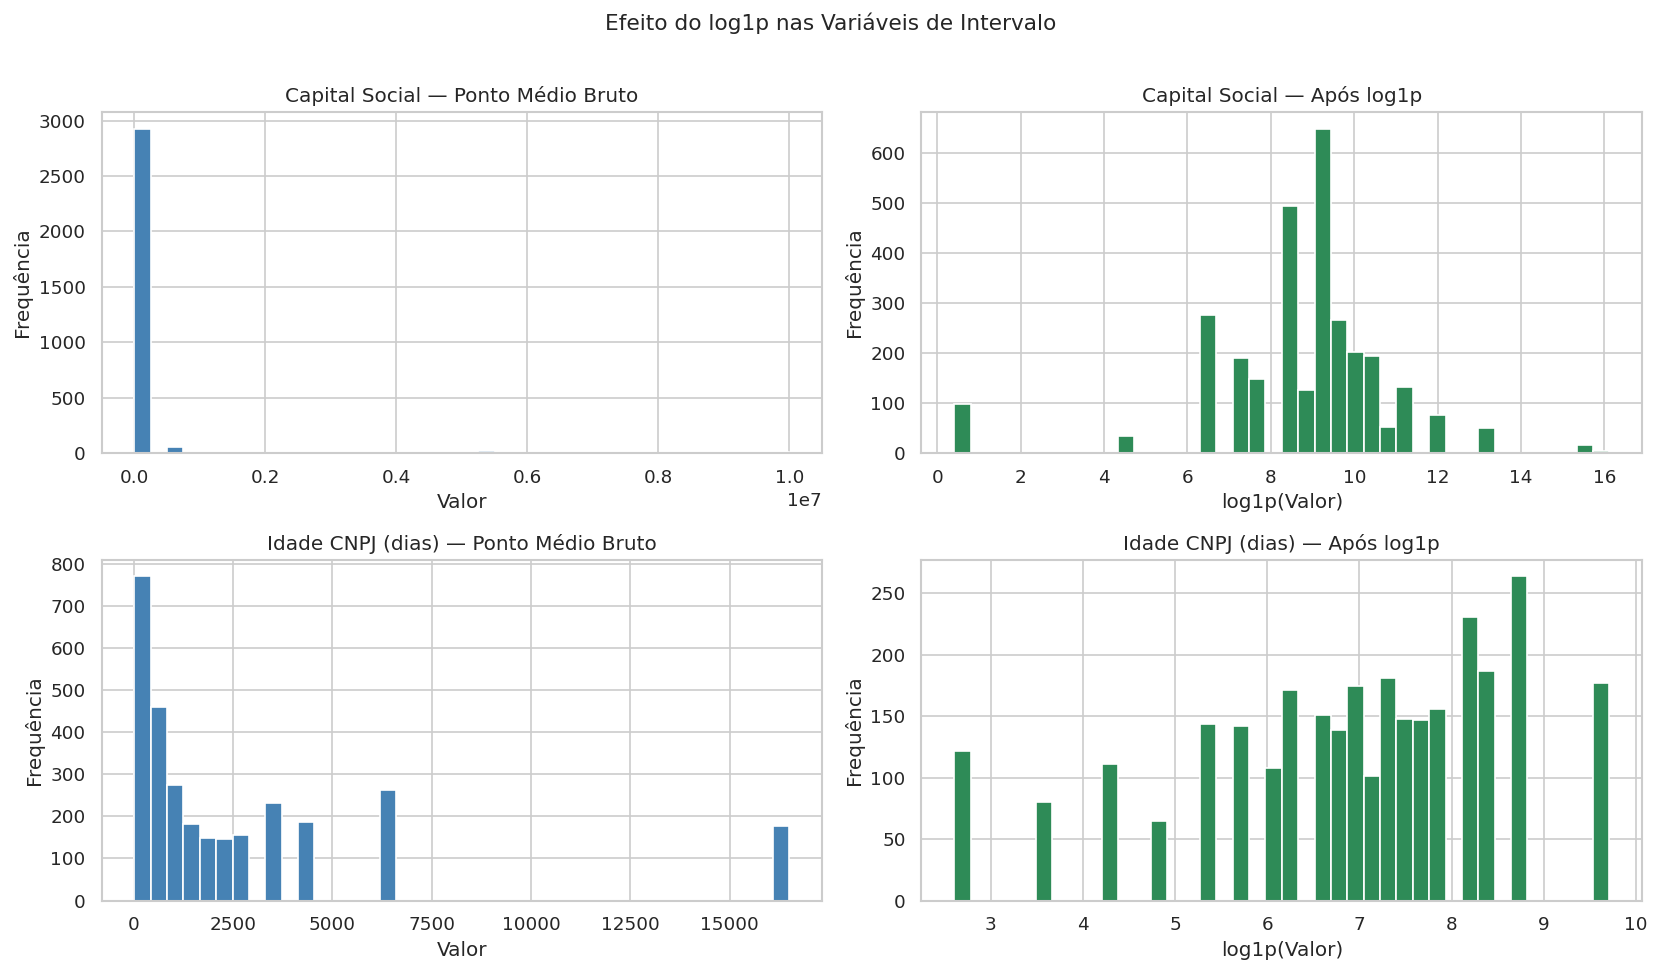

In [ ]:
# ── Visualização: antes e depois do log1p ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, (col_num, col_log, label) in enumerate([
    ("capital_social_num", "capital_social_log", "Capital Social"),
    ("idade_cnpj_num",     "idade_cnpj_log",     "Idade CNPJ (dias)"),
]):
    # Distribuição original (ponto médio bruto)
    axes[i, 0].hist(df[col_num], bins=40, color="steelblue", edgecolor="white")
    axes[i, 0].set_title(f"{label} — Ponto Médio Bruto")
    axes[i, 0].set_xlabel("Valor")
    axes[i, 0].set_ylabel("Frequência")

    # Distribuição após log1p
    axes[i, 1].hist(df[col_log], bins=40, color="seagreen", edgecolor="white")
    axes[i, 1].set_title(f"{label} — Após log1p")
    axes[i, 1].set_xlabel("log1p(Valor)")
    axes[i, 1].set_ylabel("Frequência")

plt.suptitle("Efeito do log1p nas Variáveis de Intervalo", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(
    f"{BASE_PATH}/outputs/figures/03_log1p_intervalos.png",
    dpi=150, bbox_inches="tight"
)
plt.show()

In [ ]:
# ── Remoção das colunas originais (string de intervalo) ───────────────────────
df = df.drop(columns=["capital_social", "idade_cnpj"])

# ── Assert de sanidade ────────────────────────────────────────────────────────
assert df["capital_social_num"].isnull().sum() == 0, "NaN em capital_social_num"
assert df["idade_cnpj_num"].isnull().sum()     == 0, "NaN em idade_cnpj_num"
assert df["capital_social_log"].isnull().sum() == 0, "NaN em capital_social_log"
assert df["idade_cnpj_log"].isnull().sum()     == 0, "NaN em idade_cnpj_log"

print(f"✓ Intervalos convertidos sem nulos")
print(f"Shape atual: {df.shape}")

✓ Intervalos convertidos sem nulos
Shape atual: (3000, 18)


### 3.2 — Decomposição Hierárquica do CNAE

A variável `cnae_codigo` representa a Classificação Nacional de Atividades
Econômicas do estabelecimento. Embora anonimizada, a estrutura hierárquica
original foi preservada — cada código segue o padrão `DD.GG-C-SS`, onde:

| Nível | Exemplo | Descrição |
|---|---|---|
| Divisão | `56` | 2 dígitos — nível mais agregado |
| Grupo | `56.11` | 4 dígitos após o ponto |
| Classe | `56.11-2` | Grupo + dígito após o hífen |
| Subclasse | `56.11-2-04` | Nível mais granular |

Criar features em múltiplos níveis hierárquicos permite que o notebook
de modelagem experimente diferentes granularidades e escolha empiricamente
a que melhor equilibra poder preditivo e risco de overfitting.

A subclasse (`cnae_codigo` original) não será utilizada diretamente na
modelagem — sua cardinalidade extrema inviabiliza qualquer encoding sem
agrupamento massivo.

In [ ]:
# ── Inspeção do formato antes de decompor ────────────────────────────────────
print("── Amostra de valores de cnae_codigo ──")
print(df["cnae_codigo"].dropna().sample(10, random_state=SEED).tolist())

print(f"\nNulos         : {df['cnae_codigo'].isnull().sum()}")
print(f"Únicos totais : {df['cnae_codigo'].nunique()}")

── Amostra de valores de cnae_codigo ──
['53.23-6-24', '53.23-6-24', '12.74-7-32', '39.15-7-73', '53.23-6-24', '53.23-6-24', '77.77-2-39', '77.12-9-84', '77.12-9-14', '39.87-6-92']

Nulos         : 0
Únicos totais : 153


In [ ]:
def decompor_cnae(serie: pd.Series) -> pd.DataFrame:
    """
    Decomõe uma Series de códigos CNAE no formato 'DD.GG-C-SS'
    nos níveis hierárquicos divisão, grupo e classe.

    Parâmetros
    ----------
    serie : pd.Series
        Coluna com strings de código CNAE.

    Retorna
    -------
    pd.DataFrame com colunas:
        - cnae_divisao : str  — ex: '56'
        - cnae_grupo   : str  — ex: '56.11'
        - cnae_classe  : str  — ex: '56.11-2'
    """
    # Divisão: primeiros 2 caracteres antes do ponto
    cnae_divisao = serie.str.extract(r'^(\d{2})')[0]

    # Grupo: DD.GG (antes do hífen)
    cnae_grupo = serie.str.extract(r'^(\d{2}\.\d{2})')[0]

    # Classe: DD.GG-C (até o primeiro hífen inclusive)
    cnae_classe = serie.str.extract(r'^(\d{2}\.\d{2}-\d)')[0]

    return pd.DataFrame({
        "cnae_divisao" : cnae_divisao,
        "cnae_grupo"   : cnae_grupo,
        "cnae_classe"  : cnae_classe,
    }, index=serie.index)


# ── Aplicação ─────────────────────────────────────────────────────────────────
cnae_hierarquia = decompor_cnae(df["cnae_codigo"])
df = pd.concat([df, cnae_hierarquia], axis=1)

# ── Verificação ───────────────────────────────────────────────────────────────
print("── Amostra da decomposição ──")
display(df[["cnae_codigo", "cnae_divisao", "cnae_grupo", "cnae_classe"]].sample(8, random_state=SEED))

print(f"\nNulos gerados:")
print(f"  cnae_divisao : {df['cnae_divisao'].isnull().sum()}")
print(f"  cnae_grupo   : {df['cnae_grupo'].isnull().sum()}")
print(f"  cnae_classe  : {df['cnae_classe'].isnull().sum()}")

── Amostra da decomposição ──


,cnae_codigo,cnae_divisao,cnae_grupo,cnae_classe
1801,53.23-6-24,53,53.23,53.23-6
1190,53.23-6-24,53,53.23,53.23-6
1817,12.74-7-32,12,12.74,12.74-7
251,39.15-7-73,39,39.15,39.15-7
2505,53.23-6-24,53,53.23,53.23-6
1117,53.23-6-24,53,53.23,53.23-6
1411,77.77-2-39,77,77.77,77.77-2
2113,77.12-9-84,77,77.12,77.12-9



Nulos gerados:
  cnae_divisao : 0
  cnae_grupo   : 0
  cnae_classe  : 0


In [ ]:
# ── Cardinalidade por nível hierárquico ───────────────────────────────────────
print("── Cardinalidade por nível ──\n")

for col in ["cnae_divisao", "cnae_grupo", "cnae_classe", "cnae_codigo"]:
    n_unicos = df[col].nunique()
    print(f"  {col:20s}: {n_unicos:>4} categorias únicas")

print()

# ── Distribuição de frequência — divisão ─────────────────────────────────────
freq_divisao = (
    df["cnae_divisao"]
    .value_counts()
    .reset_index()
    .rename(columns={"cnae_divisao": "divisao", "count": "n_clientes"})
)
freq_divisao["pct"] = (freq_divisao["n_clientes"] / len(df) * 100).round(2)
freq_divisao["pct_acumulado"] = freq_divisao["pct"].cumsum().round(2)

print("── Distribuição por Divisão CNAE ──")
display(freq_divisao)

── Cardinalidade por nível ──

  cnae_divisao        :   39 categorias únicas
  cnae_grupo          :  106 categorias únicas
  cnae_classe         :  111 categorias únicas
  cnae_codigo         :  153 categorias únicas

── Distribuição por Divisão CNAE ──


,divisao,n_clientes,pct,pct_acumulado
0,53,1420,47.3300,47.3300
1,77,1073,35.7700,83.1000
2,39,277,9.2300,92.3300
3,74,29,0.9700,93.3000
4,25,24,0.8000,94.1000
5,78,21,0.7000,94.8000
6,64,21,0.7000,95.5000
7,33,18,0.6000,96.1000
8,12,18,0.6000,96.7000
9,76,14,0.4700,97.1700


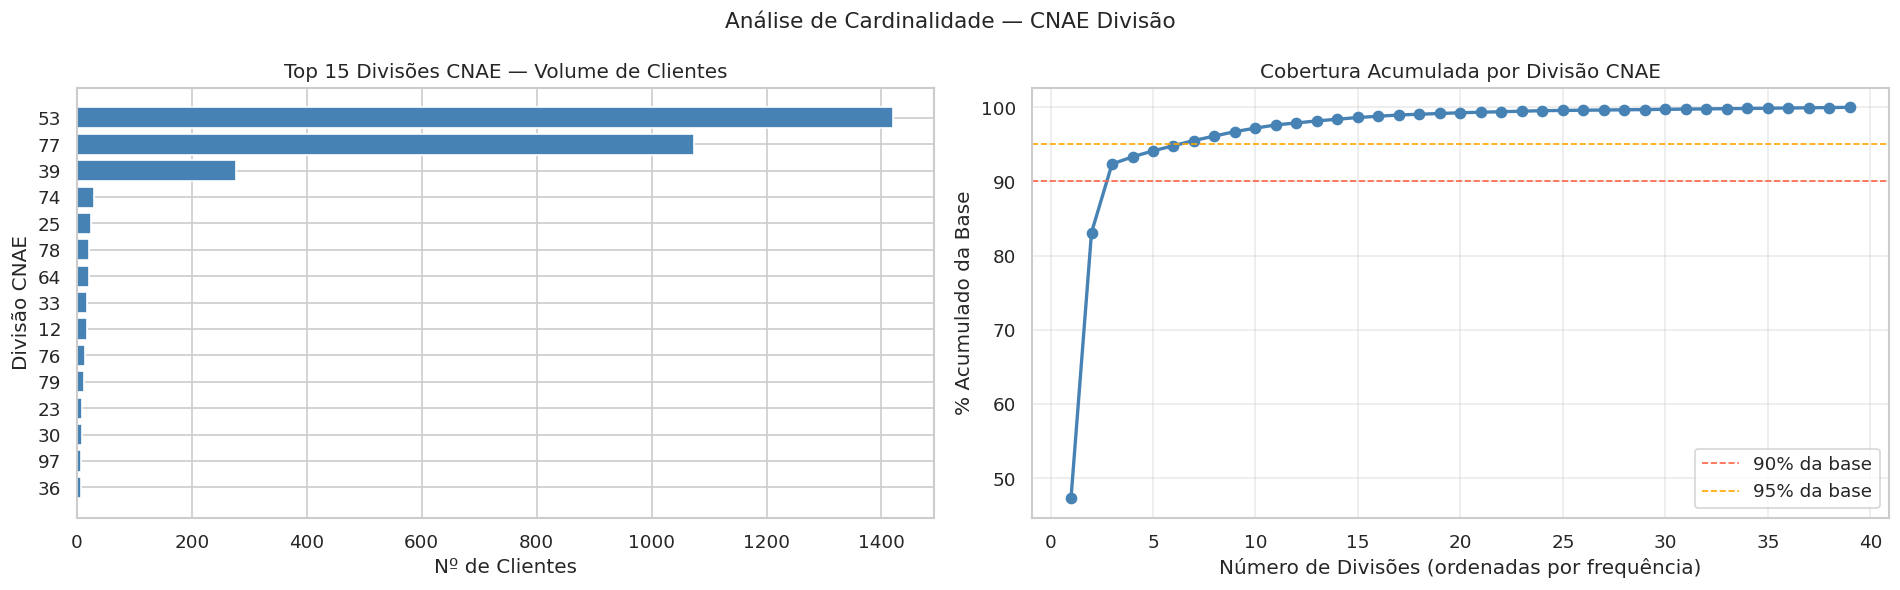

In [ ]:
# ── Visualização: cobertura acumulada por divisão ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Barplot de frequência por divisão (top 15)
top_divisoes = freq_divisao.head(15)
axes[0].barh(
    top_divisoes["divisao"].astype(str)[::-1],
    top_divisoes["n_clientes"][::-1],
    color="steelblue"
)
axes[0].set_title("Top 15 Divisões CNAE — Volume de Clientes")
axes[0].set_xlabel("Nº de Clientes")
axes[0].set_ylabel("Divisão CNAE")

# Curva de cobertura acumulada
axes[1].plot(
    range(1, len(freq_divisao) + 1),
    freq_divisao["pct_acumulado"],
    marker="o", color="steelblue", linewidth=2
)
axes[1].axhline(y=90, color="tomato", linestyle="--", linewidth=1, label="90% da base")
axes[1].axhline(y=95, color="orange", linestyle="--", linewidth=1, label="95% da base")
axes[1].set_title("Cobertura Acumulada por Divisão CNAE")
axes[1].set_xlabel("Número de Divisões (ordenadas por frequência)")
axes[1].set_ylabel("% Acumulado da Base")
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.suptitle("Análise de Cardinalidade — CNAE Divisão", fontsize=13)
plt.tight_layout()
plt.savefig(
    f"{BASE_PATH}/outputs/figures/03_cnae_divisao_cobertura.png",
    dpi=150, bbox_inches="tight"
)
plt.show()

In [ ]:
# ── Assert de sanidade ────────────────────────────────────────────────────────
assert df["cnae_divisao"].isnull().sum() == 0, "NaN em cnae_divisao"
assert df["cnae_grupo"].isnull().sum()   == 0, "NaN em cnae_grupo"
assert df["cnae_classe"].isnull().sum()  == 0, "NaN em cnae_classe"

print("✓ Decomposição CNAE concluída sem nulos")
print(f"Shape atual: {df.shape}")

✓ Decomposição CNAE concluída sem nulos
Shape atual: (3000, 21)


### Conclusão da Decomposição CNAE

A análise de cardinalidade revelou uma distribuição extremamente concentrada:

| Nível | Categorias únicas | Cobertura top 3 |
|---|---|---|
| `cnae_divisao` | 39 | ~93% da base |
| `cnae_grupo` | 106 | — |
| `cnae_classe` | 111 | — |
| `cnae_codigo` | 153 | — |

As divisões 53, 77 e 39 concentram ~93% dos clientes. As 36 divisões
restantes têm em média ~5 clientes cada — volume insuficiente para
qualquer estimativa de taxa de inadimplência estatisticamente confiável.

**Feature primária para modelagem:** `cnae_divisao`, com agrupamento de
categorias raras via target encoding com smoothing no pipeline de modelagem.
`cnae_grupo` e `cnae_classe` permanecem disponíveis para experimentos
controlados.

A coluna `cnae_codigo` (subclasse original) será removida — sua
cardinalidade de 153 categorias inviabiliza uso direto.

In [ ]:
# ── Remoção da subclasse original ────────────────────────────────────────────
df = df.drop(columns=["cnae_codigo"])

# ── Assert de sanidade ────────────────────────────────────────────────────────
assert "cnae_divisao" in df.columns
assert "cnae_grupo"   in df.columns
assert "cnae_classe"  in df.columns
assert "cnae_codigo"  not in df.columns
assert df["cnae_divisao"].isnull().sum() == 0

print("✓ Decomposição CNAE finalizada")
print(f"Shape atual: {df.shape}")

✓ Decomposição CNAE finalizada
Shape atual: (3000, 20)


### 3.3 — Engenharia de Features de Credores (Serasa)

A coluna `serasa_credores` contém uma lista de segmentos de empresas para
as quais o cliente possui dívidas registradas, no formato de string
separada por vírgulas (ex: `"Alimentos e Bebidas, Distribuição"`).

Três features serão extraídas dessa coluna:

| Feature | Tipo | Descrição |
|---|---|---|
| `tem_credores` | int8 (0/1) | Flag: cliente tem alguma dívida registrada |
| `qtd_credores` | int8 | Quantidade de credores distintos (0 a 7) |
| `credores_lista` | list | Lista limpa de segmentos — insumo para binarização no pipeline de modelagem |

A binarização por segmento (MultiLabelBinarizer) é intencionalmente
adiada para o pipeline de modelagem, onde o filtro de categorias raras
será aplicado com base exclusivamente no conjunto de treino, evitando
data leakage.

A coluna original `serasa_credores` será removida após a extração.

In [ ]:
def limpar_credores(texto) -> list:
    """
    Converte a string de credores em lista limpa de segmentos.

    - Retorna lista vazia para valores nulos
    - Padroniza para minúsculas e remove espaços extras
    - Separa apenas por vírgula — ' e ' faz parte do nome do segmento
    """
    if pd.isna(texto):
        return []

    texto = texto.lower().strip()
    categorias = [cat.strip() for cat in texto.split(',')]
    return [cat for cat in categorias if cat]


# ── Recriando as colunas com a função corrigida ───────────────────────────────
df["credores_lista"] = df["serasa_credores"].apply(limpar_credores)

df["qtd_credores"] = df["credores_lista"].apply(len).astype("int8")
df["tem_credores"] = (df["qtd_credores"] > 0).astype("int8")

# ── Verificação ───────────────────────────────────────────────────────────────
print("── Distribuição de qtd_credores ──")
print(df["qtd_credores"].value_counts().sort_index())

print(f"\n── tem_credores ──")
print(df["tem_credores"].value_counts())

── Distribuição de qtd_credores ──
qtd_credores
0    2466
1     324
2      99
3      70
4      29
5       7
6       3
7       2
Name: count, dtype: int64

── tem_credores ──
tem_credores
0    2466
1     534
Name: count, dtype: int64


In [ ]:
# ── Validação dos segmentos únicos extraídos ──────────────────────────────────
from collections import Counter

todos_segmentos = [seg for lista in df["credores_lista"] for seg in lista]
contagem = Counter(todos_segmentos)
df_segmentos = (
    pd.DataFrame(contagem.items(), columns=["segmento", "frequencia"])
    .sort_values("frequencia", ascending=False)
    .reset_index(drop=True)
)

print(f"Segmentos únicos extraídos: {len(df_segmentos)}")
print(f"\n── Frequência por segmento ──")
display(df_segmentos)

Segmentos únicos extraídos: 30

── Frequência por segmento ──


,segmento,frequencia
0,alimentos e bebidas,210
1,bancos e financeiro,198
2,tecnologia e pagamentos,89
3,distribuição,88
4,financeiro,84
5,saúde,58
6,telecomunicações,44
7,diversos,28
8,comércio,25
9,tecnologia,13


In [ ]:
# ── Remoção da coluna original ────────────────────────────────────────────────
df = df.drop(columns=["serasa_credores"])

# ── Assert de sanidade ────────────────────────────────────────────────────────
assert "tem_credores"      in df.columns
assert "qtd_credores"      in df.columns
assert "credores_lista"    in df.columns
assert "serasa_credores"   not in df.columns
assert df["tem_credores"].isnull().sum()  == 0
assert df["qtd_credores"].isnull().sum()  == 0
assert df["tem_credores"].isin([0, 1]).all()
assert df["qtd_credores"].between(0, 7).all()

print("✓ Features de credores extraídas sem nulos")
print(f"Shape atual: {df.shape}")

✓ Features de credores extraídas sem nulos
Shape atual: (3000, 22)


### 3.4 — Flags de Presença Digital

As variáveis de iFood e Google Maps possuem 82-98% de valores nulos —
não por erro de coleta, mas porque a maioria dos clientes simplesmente
não possui presença nessas plataformas. A ausência é informação, não
ruído.

Duas flags binárias serão criadas para capturar explicitamente essa
informação:

| Feature | Derivada de | Lógica |
|---|---|---|
| `tem_ifood` | `ifood_faixa_preco` | 1 se preenchido, 0 se nulo |
| `tem_google_maps` | `google_maps_avaliacao` | 1 se preenchido, 0 se nulo |

As colunas originais de iFood e Google Maps **não são removidas aqui**.
Modelos baseados em árvore lidam nativamente com valores nulos e podem
extrair sinal das variáveis originais no subconjunto de clientes onde
estão preenchidas. A decisão de incluí-las ou não na modelagem será
tomada empiricamente via importância de features no notebook 05.

In [ ]:
# ── Criação das flags com lógica OR ──────────────────────────────────────────
# Um cliente "está na plataforma" se qualquer campo dela estiver preenchido

df["tem_ifood"] = (
    df["ifood_faixa_preco"].notna() |
    df["ifood_contagem_avaliacoes"].notna()
).astype("int8")

df["tem_google_maps"] = (
    df["google_maps_avaliacao"].notna() |
    df["google_maps_contagem_avaliacoes"].notna()
).astype("int8")

# ── Verificação ───────────────────────────────────────────────────────────────
print("── tem_ifood ──")
print(df["tem_ifood"].value_counts())
print(f"  % com iFood: {df['tem_ifood'].mean()*100:.1f}%")

print("\n── tem_google_maps ──")
print(df["tem_google_maps"].value_counts())
print(f"  % com Google Maps: {df['tem_google_maps'].mean()*100:.1f}%")

# ── Diagnóstico: clientes com dados parciais ──────────────────────────────────
parcial_ifood = (
    df["ifood_faixa_preco"].notna() != df["ifood_contagem_avaliacoes"].notna()
).sum()

parcial_gmaps = (
    df["google_maps_avaliacao"].notna() != df["google_maps_contagem_avaliacoes"].notna()
).sum()

print(f"\n── Clientes com dados parciais ──")
print(f"  iFood (faixa ≠ contagem)         : {parcial_ifood}")
print(f"  Google Maps (avaliacao ≠ contagem): {parcial_gmaps}")

── tem_ifood ──
tem_ifood
0    2637
1     363
Name: count, dtype: int64
  % com iFood: 12.1%

── tem_google_maps ──
tem_google_maps
0    2792
1     208
Name: count, dtype: int64
  % com Google Maps: 6.9%

── Clientes com dados parciais ──
  iFood (faixa ≠ contagem)         : 177
  Google Maps (avaliacao ≠ contagem): 174


In [ ]:
# ── Assert de sanidade ────────────────────────────────────────────────────────
assert df["tem_ifood"].isnull().sum()       == 0
assert df["tem_google_maps"].isnull().sum() == 0
assert df["tem_ifood"].isin([0, 1]).all()
assert df["tem_google_maps"].isin([0, 1]).all()

# Garantia: flag 1 implica ao menos um campo preenchido
assert df[df["tem_ifood"] == 1]["ifood_faixa_preco"].notna().any() or \
       df[df["tem_ifood"] == 1]["ifood_contagem_avaliacoes"].notna().any()

assert df[df["tem_google_maps"] == 1]["google_maps_avaliacao"].notna().any() or \
       df[df["tem_google_maps"] == 1]["google_maps_contagem_avaliacoes"].notna().any()

print("✓ Flags de presença digital criadas")
print(f"Shape atual: {df.shape}")

✓ Flags de presença digital criadas
Shape atual: (3000, 24)


## Seção 4 — Log Transform em Variáveis de Contagem

As variáveis `serasa_contagem_negativacoes` e `serasa_contagem_protestos`
apresentam distribuições extremamente assimétricas à direita — a grande
maioria dos clientes tem valor zero, e uma minoria concentra contagens
elevadas formando uma cauda longa.

Aplicamos `log1p` para comprimir essa cauda, pelo mesmo motivo que nas
variáveis de intervalo: preservar a ordem original dos valores enquanto
reduz o impacto desproporcional de outliers extremos.

| Variável original | Variável transformada |
|---|---|
| `serasa_contagem_negativacoes` | `negativacoes_log` |
| `serasa_contagem_protestos` | `protestos_log` |

As colunas originais são mantidas — árvores não precisam do log, mas
modelos lineares se beneficiam. A escolha de qual versão entra em cada
modelo é feita no pipeline de modelagem.

In [ ]:
# ── Estatísticas antes do log ─────────────────────────────────────────────────
print("── Antes do log1p ──\n")
for col in ["serasa_contagem_negativacoes", "serasa_contagem_protestos"]:
    print(f"{col}:")
    print(df[col].describe().round(2))
    print(f"  Zeros   : {(df[col] == 0).sum()} ({(df[col] == 0).mean()*100:.1f}%)")
    print(f"  Max     : {df[col].max()}")
    print()

── Antes do log1p ──

serasa_contagem_negativacoes:
count   3000.0000
mean       1.0000
std        4.4600
min        0.0000
25%        0.0000
50%        0.0000
75%        0.0000
max      141.0000
Name: serasa_contagem_negativacoes, dtype: float64
  Zeros   : 2369 (79.0%)
  Max     : 141

serasa_contagem_protestos:
count   3000.0000
mean       0.2600
std        1.9400
min        0.0000
25%        0.0000
50%        0.0000
75%        0.0000
max       79.0000
Name: serasa_contagem_protestos, dtype: float64
  Zeros   : 2769 (92.3%)
  Max     : 79



In [ ]:
# ── Aplicação de log1p ────────────────────────────────────────────────────────
df["negativacoes_log"] = np.log1p(df["serasa_contagem_negativacoes"])
df["protestos_log"]    = np.log1p(df["serasa_contagem_protestos"])

# ── Estatísticas após log ─────────────────────────────────────────────────────
print("── Após log1p ──\n")
for col in ["negativacoes_log", "protestos_log"]:
    print(f"{col}:")
    print(df[col].describe().round(4))
    print()

── Após log1p ──

negativacoes_log:
count   3000.0000
mean       0.2902
std        0.6548
min        0.0000
25%        0.0000
50%        0.0000
75%        0.0000
max        4.9558
Name: negativacoes_log, dtype: float64

protestos_log:
count   3000.0000
mean       0.0924
std        0.3649
min        0.0000
25%        0.0000
50%        0.0000
75%        0.0000
max        4.3820
Name: protestos_log, dtype: float64



In [ ]:
# ── Assert de sanidade ────────────────────────────────────────────────────────
assert df["negativacoes_log"].isnull().sum() == 0
assert df["protestos_log"].isnull().sum()    == 0
assert (df["negativacoes_log"] >= 0).all()
assert (df["protestos_log"]    >= 0).all()

print("✓ Log transform concluído sem nulos")
print(f"Shape atual: {df.shape}")

✓ Log transform concluído sem nulos
Shape atual: (3000, 26)


### 4.1 — Encoding Ordinal: ifood_faixa_preco

A variável `ifood_faixa_preco` representa a faixa de preço do
estabelecimento no iFood. A inspeção revelou 5 valores distintos:
`$`, `$$`, `$$$`, `$$$$` e `$$$$$`.

Os dois valores mais altos (`$$$$` e `$$$$$`) somam apenas 16 clientes —
volume insuficiente para sustentar categorias próprias estatisticamente.
Ambos foram agrupados na categoria mais alta (`3`):

| Valor original | Valor codificado | n clientes |
|---|---|---|
| `$` | 1 | 284 |
| `$$` | 2 | 29 |
| `$$$` | 3 | 34 |
| `$$$$` | 3 (agrupado) | 13 |
| `$$$$$` | 3 (agrupado) | 3 |
| `NaN` | `NaN` (preservado) | 2637 |

Clientes sem presença no iFood mantêm `NaN` — a flag `tem_ifood`
já captura essa informação de forma explícita.

In [ ]:
# ── Inspeção antes do encoding ────────────────────────────────────────────────
print("── Valores únicos de ifood_faixa_preco ──")
print(df["ifood_faixa_preco"].value_counts(dropna=False))

# ── Mapeamento ordinal com agrupamento de raras na categoria mais alta ─────────
# $$$$  e $$$$$ agrupados em 3 — volume insuficiente (n=16) para categoria própria
mapa_faixa_preco = {"$": 1, "$$": 2, "$$$": 3, "$$$$": 3, "$$$$$": 3}

df["ifood_faixa_preco_ord"] = df["ifood_faixa_preco"].map(mapa_faixa_preco)

# ── Verificação ───────────────────────────────────────────────────────────────
print("\n── ifood_faixa_preco_ord ──")
print(df["ifood_faixa_preco_ord"].value_counts(dropna=False))

# Nulos devem ser exatamente iguais aos da coluna original
assert df["ifood_faixa_preco_ord"].isnull().sum() == df["ifood_faixa_preco"].isnull().sum(), \
    "Nulos inconsistentes após encoding ordinal"

# Nenhum valor mapeado fora do esperado
assert df["ifood_faixa_preco_ord"].dropna().isin([1, 2, 3]).all(), \
    "Valor inesperado após mapeamento"

print("\n✓ Encoding ordinal concluído")
print(f"Shape atual: {df.shape}")

── Valores únicos de ifood_faixa_preco ──
ifood_faixa_preco
NaN      2637
$         284
$$$        34
$$         29
$$$$       13
$$$$$       3
Name: count, dtype: int64

── ifood_faixa_preco_ord ──
ifood_faixa_preco_ord
NaN       2637
1.0000     284
3.0000      50
2.0000      29
Name: count, dtype: int64

✓ Encoding ordinal concluído
Shape atual: (3000, 27)


## Seção 5 — Validação Pós-Transformação

Esta seção recalcula o Information Value (IV) para as features derivadas
e compara com os valores obtidos na EDA. O objetivo é triplo:

1. **Validar as transformações** — confirmar que o ponto médio e o log1p
   preservaram o sinal preditivo das variáveis originais
2. **Comparar versões** — para variáveis com versão `_num` e `_log`,
   identificar qual retém mais poder preditivo
3. **Avaliar features novas** — `qtd_credores`, `tem_credores`,
   `tem_ifood`, `tem_google_maps` e `ifood_faixa_preco_ord` nunca
   tiveram IV calculado na EDA

O IV é calculado aqui sobre o dataset completo apenas para fins de
diagnóstico e comparação com a EDA — não para selecionar features,
decisão que pertence ao pipeline de modelagem com dados de treino apenas.

In [ ]:
def calcular_iv_numerica(df, coluna, target, n_bins=10):
    """
    Calcula o IV de uma variável numérica via binning quantílico.

    Parâmetros
    ----------
    df      : pd.DataFrame
    coluna  : str — nome da coluna
    target  : str — nome do target binário (0/1)
    n_bins  : int — número de bins quantílicos

    Retorna
    -------
    float — IV da variável
    """
    df_temp = df[[coluna, target]].dropna().copy()

    if df_temp[coluna].nunique() < 2:
        return 0.0

    try:
        df_temp["bin"] = pd.qcut(df_temp[coluna], q=n_bins, duplicates="drop")
    except ValueError:
        return 0.0

    total_bons = (df_temp[target] == 0).sum()
    total_maus = (df_temp[target] == 1).sum()

    agrupado = df_temp.groupby("bin", observed=True)[target].agg(
        bons=lambda x: (x == 0).sum(),
        maus=lambda x: (x == 1).sum()
    ).reset_index()

    agrupado["bons"] = agrupado["bons"].replace(0, 0.5)
    agrupado["maus"] = agrupado["maus"].replace(0, 0.5)
    agrupado["prop_bons"] = agrupado["bons"] / total_bons
    agrupado["prop_maus"] = agrupado["maus"] / total_maus
    agrupado["woe"]       = np.log(agrupado["prop_bons"] / agrupado["prop_maus"])
    agrupado["iv"]        = (agrupado["prop_bons"] - agrupado["prop_maus"]) * agrupado["woe"]

    return agrupado["iv"].sum()


def calcular_iv_categorica(df, coluna, target):
    """
    Calcula o IV de uma variável categórica ou binária.
    """
    df_temp = df[[coluna, target]].dropna().copy()

    total_bons = (df_temp[target] == 0).sum()
    total_maus = (df_temp[target] == 1).sum()

    agrupado = df_temp.groupby(coluna)[target].agg(
        bons=lambda x: (x == 0).sum(),
        maus=lambda x: (x == 1).sum()
    ).reset_index()

    agrupado["bons"] = agrupado["bons"].replace(0, 0.5)
    agrupado["maus"] = agrupado["maus"].replace(0, 0.5)
    agrupado["prop_bons"] = agrupado["bons"] / total_bons
    agrupado["prop_maus"] = agrupado["maus"] / total_maus
    agrupado["woe"]       = np.log(agrupado["prop_bons"] / agrupado["prop_maus"])
    agrupado["iv"]        = (agrupado["prop_bons"] - agrupado["prop_maus"]) * agrupado["woe"]

    return agrupado["iv"].sum()

In [ ]:
TARGET = "inadimplente"

# ── Features numéricas — comparação versão original vs derivada ───────────────
features_numericas = {
    # (coluna,                          label para tabela)
    "capital_social_num"              : "capital_social (ponto médio)",
    "capital_social_log"              : "capital_social (log1p)",
    "idade_cnpj_num"                  : "idade_cnpj (ponto médio)",
    "idade_cnpj_log"                  : "idade_cnpj (log1p)",
    "serasa_contagem_negativacoes"    : "negativacoes (original)",
    "negativacoes_log"                : "negativacoes (log1p)",
    "serasa_contagem_protestos"       : "protestos (original)",
    "protestos_log"                   : "protestos (log1p)",
    "qtd_credores"                    : "qtd_credores (nova)",
    "ifood_faixa_preco_ord"           : "ifood_faixa_preco_ord (nova)",
}

# ── Features binárias e categóricas ──────────────────────────────────────────
features_categoricas = {
    "serasa_socio_tem_negativacao"    : "socio_negativado (original)",
    "tem_credores"                    : "tem_credores (nova)",
    "tem_ifood"                       : "tem_ifood (nova)",
    "tem_google_maps"                 : "tem_google_maps (nova)",
}

resultados = []

for col, label in features_numericas.items():
    iv = calcular_iv_numerica(df, col, TARGET)
    resultados.append({"feature": label, "iv": round(iv, 4)})

for col, label in features_categoricas.items():
    iv = calcular_iv_categorica(df, col, TARGET)
    resultados.append({"feature": label, "iv": round(iv, 4)})

df_iv = (
    pd.DataFrame(resultados)
    .sort_values("iv", ascending=False)
    .reset_index(drop=True)
)

def classificar_iv(iv):
    if iv < 0.02:   return "Inútil"
    elif iv < 0.10: return "Fraco"
    elif iv < 0.30: return "Médio"
    elif iv < 0.50: return "Forte"
    else:           return "Muito Forte"

df_iv["poder_preditivo"] = df_iv["iv"].apply(classificar_iv)

print("── IV Pós-Transformação ──\n")
display(df_iv)

── IV Pós-Transformação ──



,feature,iv,poder_preditivo
0,idade_cnpj (log1p),0.3651,Forte
1,idade_cnpj (ponto médio),0.3651,Forte
2,socio_negativado (original),0.2053,Médio
3,qtd_credores (nova),0.1694,Médio
4,tem_credores (nova),0.1284,Médio
5,negativacoes (original),0.0972,Fraco
6,negativacoes (log1p),0.0972,Fraco
7,capital_social (log1p),0.0569,Fraco
8,capital_social (ponto médio),0.0569,Fraco
9,ifood_faixa_preco_ord (nova),0.0208,Fraco


In [ ]:
# ── Comparação com IV da EDA ──────────────────────────────────────────────────
iv_eda = {
    "idade_cnpj"                   : 0.3651,
    "serasa_socio_tem_negativacao" : 0.2053,
    "serasa_contagem_negativacoes" : 0.1117,
    "qtd_credores (EDA)"           : 0.1694,
    "fonte_cliente"                : 0.0800,
    "serasa_contagem_protestos"    : 0.0082,
}

print("── Comparação: EDA vs Pós-Transformação ──\n")
print(f"  {'Feature':<40} {'IV EDA':>8} {'IV Atual':>10} {'Variação':>10}")
print(f"  {'─'*70}")

pares_comparacao = [
    ("idade_cnpj (ponto médio)",   "idade_cnpj",                   "idade_cnpj"),
    ("negativacoes (original)",    "serasa_contagem_negativacoes", "serasa_contagem_negativacoes"),
    ("protestos (original)",       "serasa_contagem_protestos",    "serasa_contagem_protestos"),
    ("qtd_credores (nova)",        "qtd_credores (EDA)",           "qtd_credores"),
]

for label_atual, label_eda, _ in pares_comparacao:
    iv_atual = df_iv[df_iv["feature"] == label_atual]["iv"].values
    iv_e     = iv_eda.get(label_eda, None)

    if len(iv_atual) > 0 and iv_e:
        iv_a    = iv_atual[0]
        variacao = ((iv_a - iv_e) / iv_e * 100)
        sinal   = "▲" if variacao > 0 else "▼"
        print(f"  {label_atual:<40} {iv_e:>8.4f} {iv_a:>10.4f} {sinal}{abs(variacao):>8.1f}%")

── Comparação: EDA vs Pós-Transformação ──

  Feature                                    IV EDA   IV Atual   Variação
  ──────────────────────────────────────────────────────────────────────
  idade_cnpj (ponto médio)                   0.3651     0.3651 ▼     0.0%
  negativacoes (original)                    0.1117     0.0972 ▼    13.0%
  protestos (original)                       0.0082     0.0000 ▼   100.0%
  qtd_credores (nova)                        0.1694     0.1694 ▼     0.0%


### 5.1 — Conclusões da Validação Pós-Transformação

#### Validação das Transformações

| Feature | IV EDA | IV Atual | Status |
|---|---|---|---|
| `idade_cnpj` | 0.3651 | 0.3651 | ✓ Sinal preservado |
| `negativacoes` | 0.1117 | 0.0972 | ✓ Queda esperada (discretização) |
| `qtd_credores` | 0.1694 | 0.1694 | ✓ Sinal preservado integralmente |
| `protestos` | 0.0082 | 0.0000 | ⚠ Confirmado sem poder preditivo |

#### log1p vs Ponto Médio

O IV calculado via binning quantílico é invariante a transformações
monotônicas — log1p e ponto médio produzem IVs idênticos porque as
observações mantêm a mesma ordem relativa. A diferença entre as duas
versões será capturada na modelagem, especialmente para Regressão
Logística, onde a distribuição das features impacta diretamente os
coeficientes.

**Decisão:** manter ambas as versões no artefato final. O pipeline de
modelagem selecionará a versão adequada para cada algoritmo.

#### Features Novas

| Feature | IV | Classificação | Decisão |
|---|---|---|---|
| `tem_credores` | 0.1284 | Médio | ✓ Manter |
| `qtd_credores` | 0.1694 | Médio | ✓ Manter |
| `ifood_faixa_preco_ord` | 0.0208 | Fraco | Avaliar na modelagem |
| `tem_ifood` | 0.0066 | Inútil | Avaliar na modelagem |
| `tem_google_maps` | 0.0049 | Inútil | Avaliar na modelagem |

#### Candidatas a Exclusão no Pipeline de Modelagem

- `serasa_contagem_protestos` e `protestos_log`: IV zero — sem poder
  discriminatório. Remoção recomendada antes do treino.
- `tem_ifood` e `tem_google_maps`: IV inútil — presença nas plataformas
  digitais não discrimina risco de inadimplência nesta base.
- `ifood_faixa_preco_ord`: sinal marginal com base muito pequena (n=363).
  Manter como candidata mas com baixa expectativa de contribuição.

Nenhuma feature é removida aqui — as decisões de exclusão são tomadas
no pipeline de modelagem com validação cruzada, garantindo que o
descarte seja empiricamente justificado e não apenas baseado em IV.

## Seção 6 — Inventário Final de Features

Antes de salvar os artefatos, documentamos o estado completo do dataset:
todas as colunas presentes, seus tipos, origens, transformações aplicadas
e papel no pipeline de modelagem.

Esta seção serve como contrato entre o notebook de preprocessing (03) e
o notebook de modelagem (05) — qualquer decisão tomada aqui deve ser
refletida no pipeline subsequente.

In [ ]:
# Inventário completo das colunas
inventario = [
    # Coluna                              Tipo         Origem        Nulos    Papel
    # TARGET
    ("inadimplente",                     "int8",      "original",   "zero",  "target"),

    # FEATURES ORIGINAIS MANTIDAS
    ("municipio",                        "object",    "original",   "zero",  "pipeline → encoding"),
    ("segmento_cliente",                 "object",    "original",   "zero",  "pipeline → target encoding"),
    ("natureza_juridica",                "object",    "original",   "zero",  "pipeline → encoding"),
    ("fonte_cliente",                    "object",    "original",   "zero",  "pipeline → encoding"),
    ("serasa_contagem_negativacoes",     "int64",     "original",   "zero",  "modelagem (ou log1p)"),
    ("serasa_contagem_protestos",        "int64",     "original",   "zero",  "avaliar exclusão"),
    ("serasa_socio_tem_negativacao",     "int8",      "original",   "zero",  "modelagem"),
    ("ifood_contagem_avaliacoes",        "float64",    "original",   "sim",   "modelagem"),
    ("google_maps_avaliacao",            "float64",    "original",   "sim",   "modelagem"),
    ("google_maps_contagem_avaliacoes",  "float64",    "original",   "sim",   "modelagem"),

    # FEATURES DERIVADAS — INTERVALOS
    ("capital_social_num",               "float64",   "derivada",   "zero",  "modelagem (árvores)"),
    ("capital_social_log",               "float64",   "derivada",   "zero",  "modelagem (linear)"),
    ("idade_cnpj_num",                   "float64",   "derivada",   "zero",  "modelagem (árvores)"),
    ("idade_cnpj_log",                   "float64",   "derivada",   "zero",  "modelagem (linear)"),

    # FEATURES DERIVADAS — CNAE─
    ("cnae_divisao",                     "object",    "derivada",   "zero",  "pipeline → target encoding"),
    ("cnae_grupo",                       "object",    "derivada",   "zero",  "experimento controlado"),
    ("cnae_classe",                      "object",    "derivada",   "zero",  "experimento controlado"),

    # FEATURES DERIVADAS — CREDORES─
    ("credores_lista",                   "object",    "derivada",   "zero",  "pipeline → MultiLabelBinarizer"),
    ("qtd_credores",                     "int8",      "derivada",   "zero",  "modelagem"),
    ("tem_credores",                     "int8",      "derivada",   "zero",  "modelagem"),

    # FEATURES DERIVADAS — PRESENÇA DIGITAL
    ("tem_ifood",                        "int8",      "derivada",   "zero",  "avaliar exclusão"),
    ("tem_google_maps",                  "int8",      "derivada",   "zero",  "avaliar exclusão"),

    # FEATURES DERIVADAS — ENCODING ORDINAL
    ("ifood_faixa_preco_ord",            "float64",   "derivada",   "sim",   "avaliar exclusão"),

    # FEATURES DERIVADAS — LOG TRANSFORM─
    ("negativacoes_log",                 "float64",   "derivada",   "zero",  "modelagem (linear)"),
    ("protestos_log",                    "float64",   "derivada",   "zero",  "avaliar exclusão"),
]

df_inventario = pd.DataFrame(
    inventario,
    columns=["coluna", "tipo", "origem", "tem_nulos", "papel"]
)

print(f"Total de colunas no dataset: {df.shape[1]}")
print(f"Total no inventário        : {len(df_inventario)}")
print()
display(df_inventario)

Total de colunas no dataset: 26
Total no inventário        : 26



,coluna,tipo,origem,tem_nulos,papel
0,inadimplente,int8,original,zero,target
1,municipio,object,original,zero,pipeline → encoding
2,segmento_cliente,object,original,zero,pipeline → target encoding
3,natureza_juridica,object,original,zero,pipeline → encoding
4,fonte_cliente,object,original,zero,pipeline → encoding
5,serasa_contagem_negativacoes,int64,original,zero,modelagem (ou log1p)
6,serasa_contagem_protestos,int64,original,zero,avaliar exclusão
7,serasa_socio_tem_negativacao,int8,original,zero,modelagem
8,ifood_contagem_avaliacoes,float64,original,sim,modelagem
9,google_maps_avaliacao,float64,original,sim,modelagem


In [ ]:
# ── Validação cruzada: inventário bate com o dataset ─────────────────────────
colunas_dataset    = set(df.columns)
colunas_inventario = set(df_inventario["coluna"])

apenas_dataset    = colunas_dataset - colunas_inventario
apenas_inventario = colunas_inventario - colunas_dataset

if apenas_dataset:
    print(f"⚠ Colunas no dataset mas fora do inventário: {apenas_dataset}")
if apenas_inventario:
    print(f"⚠ Colunas no inventário mas fora do dataset: {apenas_inventario}")
if not apenas_dataset and not apenas_inventario:
    print("✓ Inventário e dataset estão sincronizados")

# ── Resumo por origem e papel ─────────────────────────────────────────────────
print("\n── Colunas por origem ──")
print(df_inventario["origem"].value_counts())

print("\n── Colunas por papel ──")
print(df_inventario["papel"].value_counts())

# ── Nulos remanescentes por coluna ───────────────────────────────────────────
print("\n── Nulos remanescentes (nulos estruturais esperados) ──")
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
for col, n in nulos.items():
    pct = n / len(df) * 100
    print(f"  {col:<40} {n:>5} nulos ({pct:.1f}%)")

✓ Inventário e dataset estão sincronizados

── Colunas por origem ──
origem
derivada    15
original    12
Name: count, dtype: int64

── Colunas por papel ──
papel
avaliar exclusão                  5
pipeline → encoding               3
modelagem                         3
pipeline → ponto médio            3
modelagem (linear)                3
experimento controlado            2
pipeline → target encoding        2
modelagem (árvores)               2
modelagem (ou log1p)              1
target                            1
substituída por _ord              1
pipeline → MultiLabelBinarizer    1
Name: count, dtype: int64

── Nulos remanescentes (nulos estruturais esperados) ──
  google_maps_avaliacao                     2966 nulos (98.9%)
  ifood_contagem_avaliacoes                 2814 nulos (93.8%)
  google_maps_contagem_avaliacoes           2792 nulos (93.1%)
  ifood_faixa_preco                         2637 nulos (87.9%)
  ifood_faixa_preco_ord                     2637 nulos (87.9%)


In [ ]:
# Resumo final do datase
print("── Resumo Final do Dataset ──\n")
print(f"  Shape                    : {df.shape}")
print(f"  Linhas                   : {df.shape[0]:,}")
print(f"  Colunas totais           : {df.shape[1]}")
print(f"  Colunas originais        : {(df_inventario['origem'] == 'original').sum()}")
print(f"  Colunas derivadas        : {(df_inventario['origem'] == 'derivada').sum()}")
print(f"  Memória ocupada          : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\n  Taxa de inadimplência    : {df['inadimplente'].mean()*100:.1f}%")
print(f"  Nulos estruturais        : {df.isnull().sum().sum()} valores")
print(f"  Colunas sem nulos        : {(df.isnull().sum() == 0).sum()}")
print(f"  Colunas com nulos        : {(df.isnull().sum() > 0).sum()}")

── Resumo Final do Dataset ──

  Shape                    : (3000, 27)
  Linhas                   : 3,000
  Colunas totais           : 27
  Colunas originais        : 12
  Colunas derivadas        : 15
  Memória ocupada          : 2.14 MB

  Taxa de inadimplência    : 31.3%
  Nulos estruturais        : 13846 valores
  Colunas sem nulos        : 22
  Colunas com nulos        : 5


## Seção 7 — Salvamento dos Artefatos

Esta seção salva os artefatos produzidos pelo notebook de preprocessing
em dois arquivos distintos:

| Artefato | Formato | Conteúdo |
|---|---|---|
| `aplicacao_features.parquet` | Parquet | Dataset completo transformado sem o target |
| `aplicacao_target.parquet` | Parquet | `id_cliente` + `inadimplente` |

O merge entre os dois arquivos — e com o dataset comportamental — é feito pelo
`id_cliente`, presente em ambos os artefatos, imediatamente antes do train/test split.

**Por que Parquet?**
Parquet preserva os tipos de cada coluna — inteiros, floats, strings e
listas — exatamente como foram definidos aqui. Um CSV perderia essa
informação e exigiria recasts manuais no notebook de modelagem.

**Nota sobre `credores_lista`:**
Colunas do tipo lista não são suportadas nativamente pelo Parquet. A
coluna será serializada como string JSON e desserializada no notebook 05.

In [ ]:
import os

os.makedirs(PROCESSED_PATH, exist_ok=True)

# Separacao features / target
colunas_remover_features = ["inadimplente", "credores_lista"]

# Conversao das colunas intervalares pendentes (consistencia com capital_social e idade_cnpj)
colunas_intervalo_pendentes = [
    "ifood_contagem_avaliacoes",
    "google_maps_avaliacao",
    "google_maps_contagem_avaliacoes",
]
for col in colunas_intervalo_pendentes:
    df[col] = intervalo_para_valor_representativo(df[col])

# Drop da faixa de preco original (ja substituida por ifood_faixa_preco_ord)
df = df.drop(columns=["ifood_faixa_preco"])
df_features = df.drop(columns=colunas_remover_features).copy()

# id_cliente incluido como coluna-chave (primeira posicao) para permitir
# merge por chave no notebook 04, eliminando a reanexacao posicional fragil.
# Sem valor preditivo: sera removido antes do fit dentro do pipeline.
df_features.insert(0, "id_cliente", id_cliente.values)

df_target = pd.DataFrame({
    "id_cliente"  : id_cliente.values,
    "inadimplente": df["inadimplente"].values
})

print(f"df_features shape : {df_features.shape}")
print(f"df_target shape   : {df_target.shape}")
print(f"id_cliente em features : {'id_cliente' in df_features.columns}")
print(f"id_cliente unico       : {df_features['id_cliente'].is_unique}")
print()
print("Colunas em df_features:")
print(df_features.columns.tolist())

df_features shape : (3000, 25)
df_target shape   : (3000, 2)
id_cliente em features : True
id_cliente unico       : True

Colunas em df_features:
['id_cliente', 'municipio', 'segmento_cliente', 'natureza_juridica', 'fonte_cliente', 'serasa_contagem_negativacoes', 'serasa_contagem_protestos', 'serasa_socio_tem_negativacao', 'ifood_contagem_avaliacoes', 'google_maps_avaliacao', 'google_maps_contagem_avaliacoes', 'capital_social_num', 'idade_cnpj_num', 'capital_social_log', 'idade_cnpj_log', 'cnae_divisao', 'cnae_grupo', 'cnae_classe', 'qtd_credores', 'tem_credores', 'tem_ifood', 'tem_google_maps', 'negativacoes_log', 'protestos_log', 'ifood_faixa_preco_ord']


In [ ]:
# Salvamento dos datasets
path_features = f"{PROCESSED_PATH}/aplicacao_features.parquet"
path_target   = f"{PROCESSED_PATH}/aplicacao_target.parquet"

df_features.to_parquet(path_features, index=False)
df_target.to_parquet(path_target,     index=False)

print(f"✓ aplicacao_features.parquet salvo — {df_features.shape}")
print(f"✓ aplicacao_target.parquet salvo   — {df_target.shape}")

# Verificação de integridade
df_feat_check = pd.read_parquet(path_features)
df_targ_check = pd.read_parquet(path_target)

assert df_feat_check.shape   == df_features.shape,   "Shape de features inconsistente"
assert df_targ_check.shape   == df_target.shape,     "Shape de target inconsistente"
assert "inadimplente" not in df_feat_check.columns,  "Target vazou para features"
assert "inadimplente" in df_targ_check.columns,      "Target ausente no arquivo de target"

print("\n✓ Integridade dos arquivos verificada")

✓ aplicacao_features.parquet salvo — (3000, 25)
✓ aplicacao_target.parquet salvo   — (3000, 2)

✓ Integridade dos arquivos verificada
